Electoral Bonds


Electoral Bond was a mode of funding to the political parties in India. It is a type of instrument that functions like a Promissory Note and an interest-free banking tool. Any Indian citizen or organization registered in India can buy these bonds after fulfilling the KYC norms laid down by the RBI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
buyer=pd.read_csv("electroral_bonds_buyer_data.csv",index_col=0)
receiver=pd.read_csv("rec_data.csv",usecols=['DateEncashment','PartyName','Denominations'])

DATA CLEANING


In [3]:
buyer['Date']=pd.to_datetime(buyer['Date of Purchase'])
donors=buyer.drop('Date of Purchase',axis=1)
donors.set_index('Date',inplace=True) 
donors.columns=['Donor','Amount'] #rename
print('sample data of donors')
donors.sample

sample data of donors


<bound method NDFrame.sample of                                      Donor    Amount
Date                                                
2019-04-12             A B C INDIA LIMITED    100000
2019-04-12             A B C INDIA LIMITED    100000
2019-04-12             A B C INDIA LIMITED   1000000
2019-04-12             A B C INDIA LIMITED   1000000
2019-04-12             A B C INDIA LIMITED    100000
...                                    ...       ...
2024-01-11  WESTWELL GASES PRIVATE LIMITED  10000000
2024-01-11  WESTWELL GASES PRIVATE LIMITED  10000000
2024-01-11  WESTWELL GASES PRIVATE LIMITED  10000000
2024-01-11  WESTWELL GASES PRIVATE LIMITED  10000000
2024-01-11  WESTWELL GASES PRIVATE LIMITED  10000000

[18871 rows x 2 columns]>

In [4]:
receiver.rename(columns={'DateEncashment': 'Date',
                         'PartyName': 'Party',
                         'Denominations':'Amount'},inplace=True)
receiver['Date']= pd.to_datetime(receiver['Date'])
receiver.set_index('Date',inplace=True)
print("sample data of amt received by parties")
receiver.sample


sample data of amt received by parties


<bound method NDFrame.sample of                                                Party    Amount
Date                                                          
2019-04-12  ALL INDIA ANNA DRAVIDA MUNNETRA KAZHAGAM  10000000
2019-04-12  ALL INDIA ANNA DRAVIDA MUNNETRA KAZHAGAM  10000000
2019-04-12  ALL INDIA ANNA DRAVIDA MUNNETRA KAZHAGAM  10000000
2019-04-12  ALL INDIA ANNA DRAVIDA MUNNETRA KAZHAGAM   1000000
2019-04-12  ALL INDIA ANNA DRAVIDA MUNNETRA KAZHAGAM   1000000
...                                              ...       ...
2024-01-24                            JANASENA PARTY   1000000
2024-01-24                            JANASENA PARTY   1000000
2024-01-24                            JANASENA PARTY   1000000
2024-01-24                            JANASENA PARTY   1000000
2024-01-24                            JANASENA PARTY   1000000

[20421 rows x 2 columns]>

In [5]:
# Load only the required columns
receiver = pd.read_csv("rec_data.csv", usecols=['DateEncashment', 'PartyName', 'Denominations'])

# Fix date format BEFORE renaming or setting index
receiver['DateEncashment'] = pd.to_datetime(receiver['DateEncashment'])

# Set Date as index
receiver.set_index('DateEncashment', inplace=True)

# Rename remaining columns only (Date is now index, not a column)
receiver.rename(columns={
    'PartyName': 'Political Party',
    'Denominations': 'Amount Received'
}, inplace=True)

print("Sample data:")
receiver.sample(4)

Sample data:


,Political Party,Amount Received
DateEncashment,,
2023-01-30,BHARATIYA JANATA PARTY,10000000
2021-07-12,ALL INDIA TRINAMOOL CONGRESS,10000000
2021-04-12,BHARATIYA JANATA PARTY,10000000
2019-05-10,BHARATIYA JANATA PARTY,10000000


Political Parties


The datset timeline is from 12 April 2019 to 11 Jan 2024. 27 Unique Polital Parties received funds from Electoral Bonds.

In [6]:
party_funds=receiver.groupby("Political Party")['Amount Received'].sum().reset_index()
total_amount_received=party_funds['Amount Received'].sum()
party_funds['Percentage']=(party_funds['Amount Received']/total_amount_received*100)

party_funds = party_funds.sort_values(by='Percentage',ascending=False)
party_pie=party_funds.head(8)

<function matplotlib.pyplot.show(close=None, block=None)>

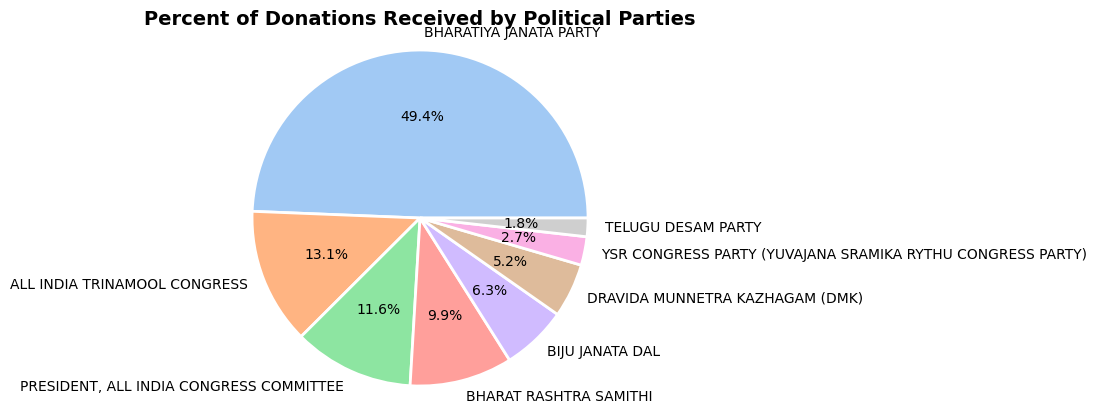

In [7]:
plt.Figure(figsize=(7,7))
colors =sns.color_palette('pastel')
plt.pie(party_pie['Amount Received'],labels=party_pie['Political Party'],autopct='%1.1f%%' ,colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Percent of Donations Received by Political Parties',fontsize=14,fontweight='bold')
plt.axis('equal')
plt.show

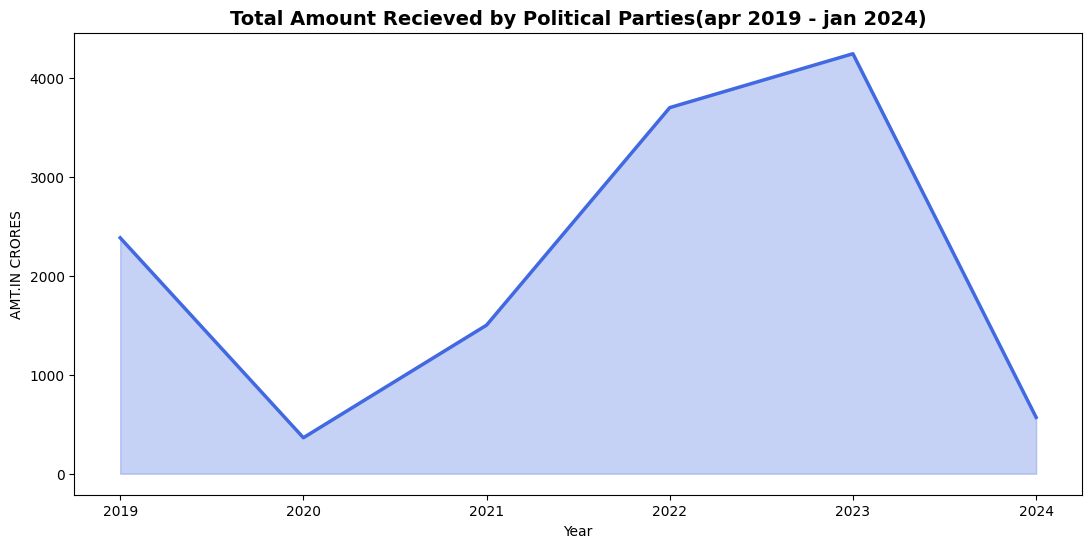

In [8]:
party_funds=receiver.groupby(['DateEncashment','Political Party']) ['Amount Received'].sum().reset_index()
party_funds['Year']=party_funds['DateEncashment'].dt.year

yearly_funds_received =party_funds.groupby('Year')['Amount Received'].sum().reset_index()

yearly_funds_received['Amount Received']=yearly_funds_received["Amount Received"]/10000000

plt.figure(figsize=(13,6))
sns.lineplot(x='Year',y='Amount Received',data=yearly_funds_received,color='royalblue',linewidth=2.5)

plt.fill_between(yearly_funds_received['Year'],
                 yearly_funds_received['Amount Received'],
                 alpha=0.3,
                 color='royalblue')
plt.title('Total Amount Recieved by Political Parties(apr 2019 - jan 2024)',fontsize=14,fontweight='bold')
plt.xlabel('Year')
plt.ylabel('AMT.IN CRORES')
plt.show()


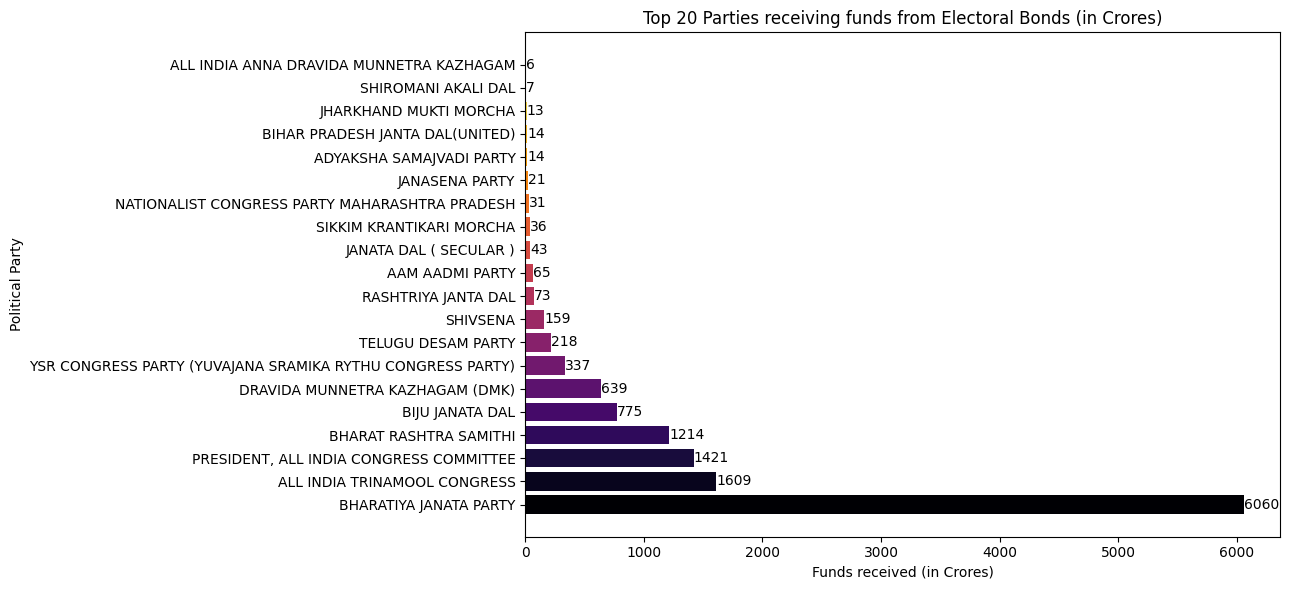

In [9]:
party_funds1=party_funds.groupby('Political Party')['Amount Received'].sum().reset_index()
party_funds1=party_funds1.sort_values(by='Amount Received',ascending=False)
party_funds1['Received Amount'] = party_funds1['Amount Received']/10000000
party_fund20=party_funds1[['Political Party', 'Received Amount']]
top20=party_fund20.head(20)

num_colors=len(top20)

# Generate a range of colors using a gradient
colors = plt.cm.inferno(np.linspace(0, 1, num_colors))
plt.figure(figsize=(13,6))

bar=plt.barh(top20['Political Party'],top20["Received Amount"],color=colors)


# Add labels for the bars
for bar, value in zip(bar, top20['Received Amount']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{int(value)}',
             va='center', ha='left') 

plt.title("Top 20 Parties receiving funds from Electoral Bonds (in Crores)")
plt.xlabel("Funds received (in Crores)")
plt.ylabel('Political Party')
plt.tight_layout()
plt.show()




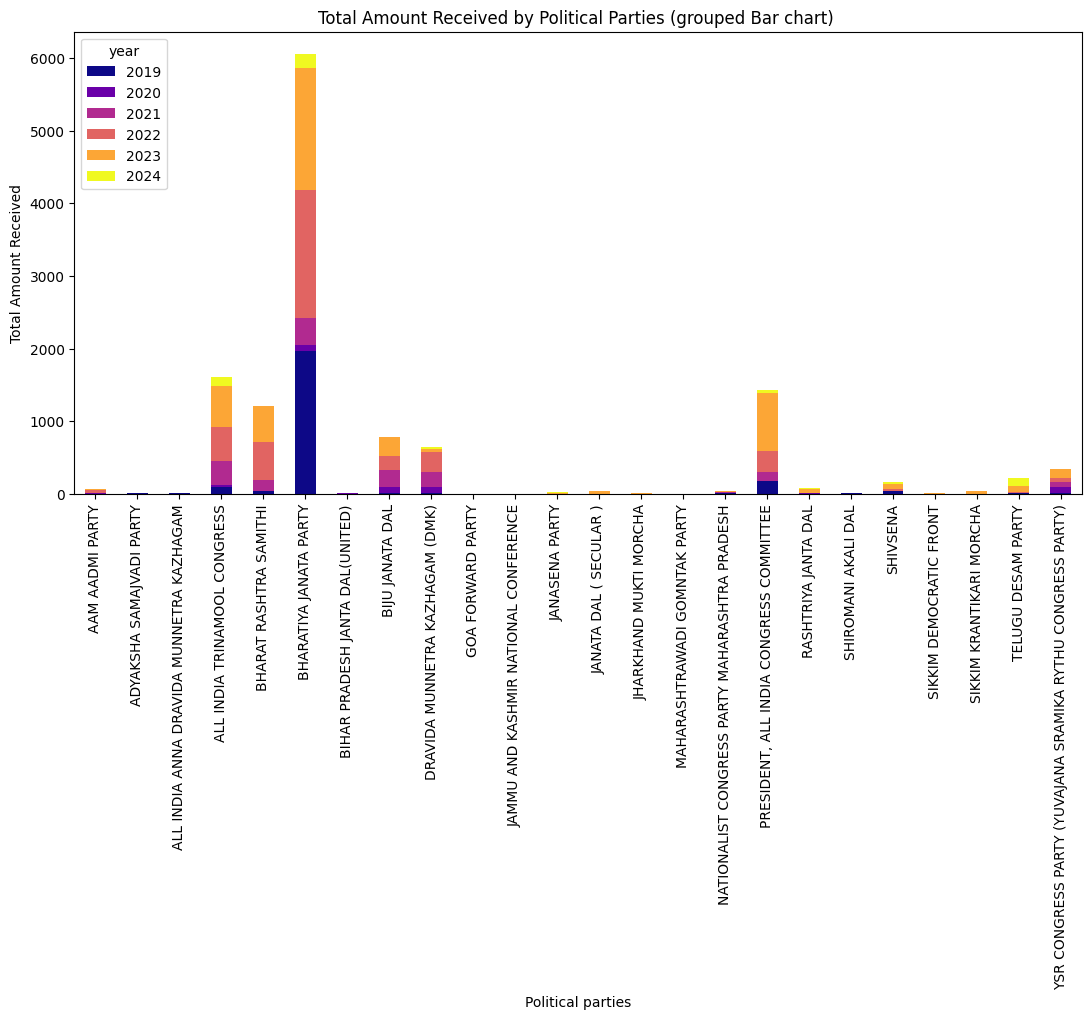

In [10]:
grouped_data=party_funds.groupby(['Political Party','Year'])['Amount Received'].sum().reset_index()

#new column in crores
grouped_data['Received Amount']=grouped_data['Amount Received']/10000000

#pivot for year as columns
pivoted_data=grouped_data.pivot(index='Political Party',columns='Year',values="Received Amount").fillna(0)

plt.figure(figsize=(13,6))
pivoted_data.plot(kind='bar',stacked=True,colormap='plasma',ax=plt.gca())
plt.title('Total Amount Received by Political Parties (grouped Bar chart) ')
plt.xlabel('Political parties')
plt.ylabel('Total Amount Received')
plt.xticks(rotation=90)
plt.legend(title='year',loc='upper left')
plt.show()

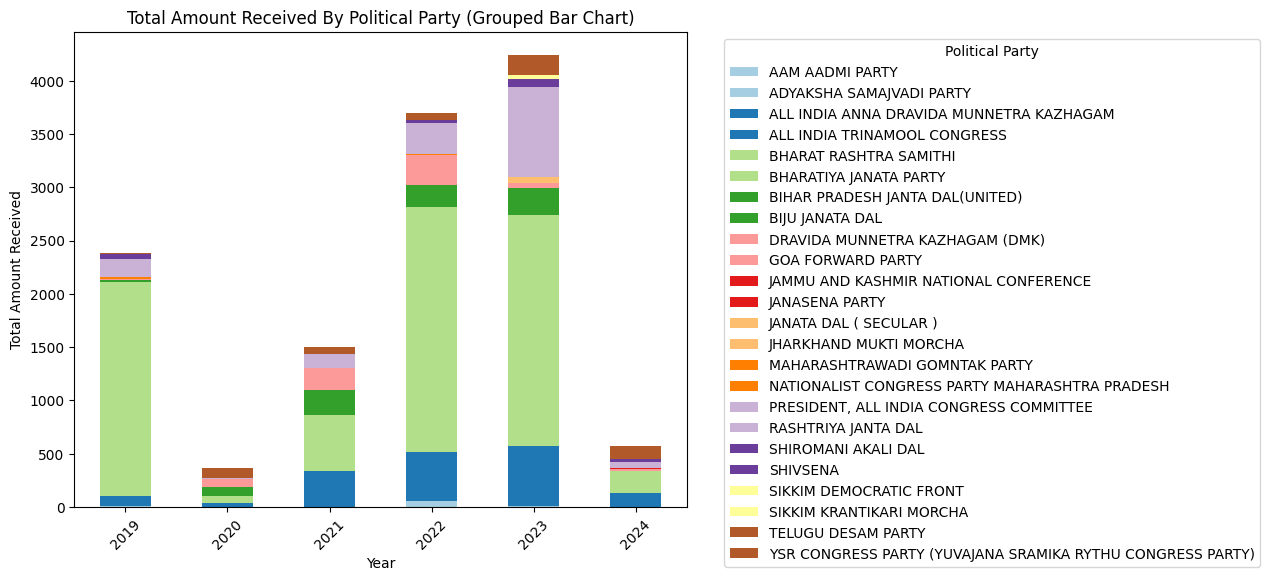

In [11]:
cleaned_data=grouped_data.pivot(index='Year',columns='Political Party', values='Received Amount').fillna(0)

plt.figure(figsize=(13,6))
cleaned_data.plot(kind='bar',stacked=True,colormap='Paired',ax=plt.gca())
plt.title('Total Amount Received By Political Party (Grouped Bar Chart)')
plt.xlabel('Year')
plt.ylabel('Total Amount Received')
plt.xticks(rotation=45)
plt.legend(title="Political Party", bbox_to_anchor=(1.05, 1),loc='upper left')
plt.tight_layout()
plt.show()

Denominations


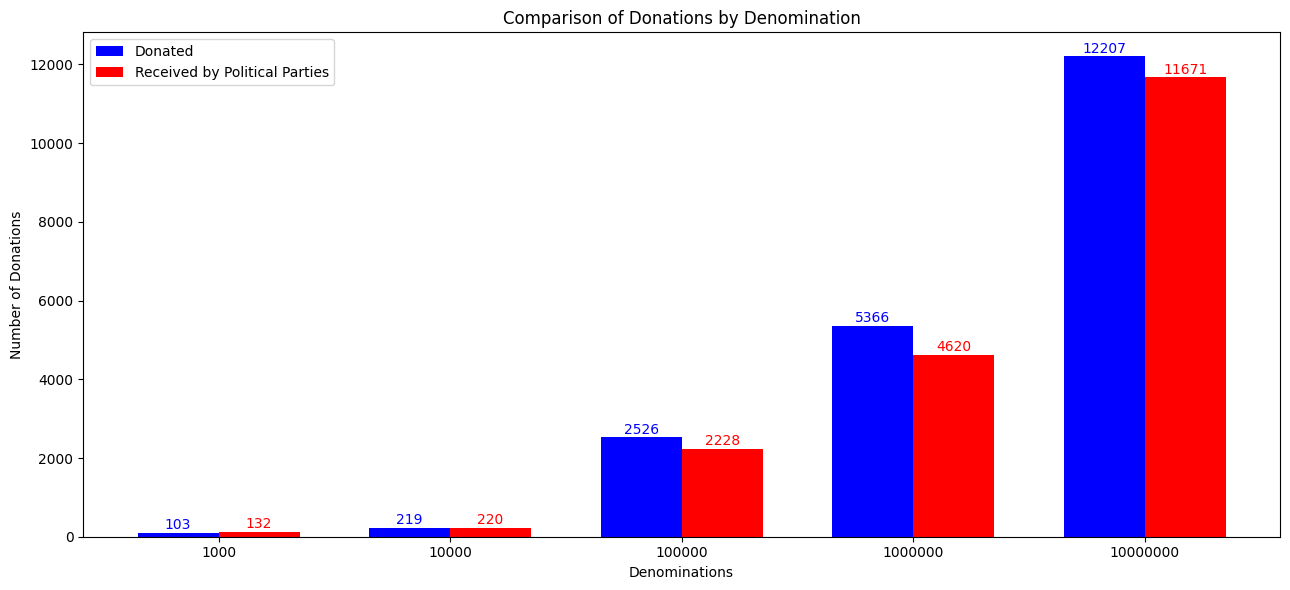

In [12]:
Denominations_Donor = donors['Amount'].value_counts().reset_index()
#rename
Denominations_Donor.columns=['Denominations','No of Donations']

Denominations_party = receiver['Amount Received'].value_counts().reset_index()

#rename
Denominations_party.columns=['Denominations','Donations_count']

con=pd.merge(Denominations_party,Denominations_Donor,on='Denominations',how='outer') #merged donated and received


plt.figure(figsize=(13,6))
bar_width = 0.35
bar_position = range(len(con))

plt.bar(bar_position,con["Donations_count"],bar_width,label='Donated',color='blue')
plt.bar([pos + bar_width for pos in bar_position], con['No of Donations'], bar_width, label='Received by Political Parties', color='red')

#labels for each bar
for i, (value1, value2) in enumerate(zip(con['Donations_count'], con['No of Donations'])):
    plt.text(i, value1 + 20, str(value1), ha='center', va='bottom', color='blue')
    plt.text(i + bar_width, value2 + 20, str(value2), ha='center', va='bottom', color='red')
plt.xlabel('Denominations')
plt.ylabel('Number of Donations')
plt.title('Comparison of Donations by Denomination')
plt.xticks([pos + bar_width / 2 for pos in bar_position], con['Denominations'])
plt.legend()
plt.tight_layout()
plt.show()

DONORS



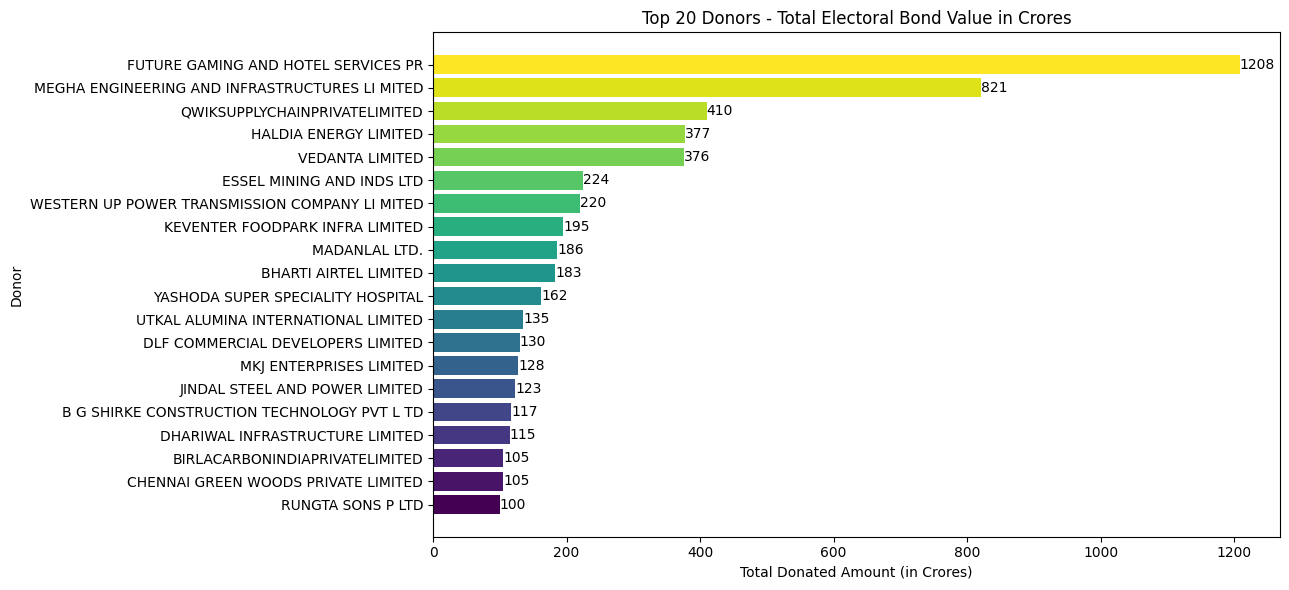

In [13]:
total_bought = donors.groupby('Donor')['Amount'].sum().reset_index()
total_bought = total_bought.sort_values(by='Amount', ascending=False)
total_bought['Total_Bond_Value_in_Crores'] = round(total_bought['Amount'] / 10000000, 0)

total_bought = total_bought.drop('Amount', axis=1)
top20_values = total_bought.head(20)

top20_values = top20_values.sort_values(by='Total_Bond_Value_in_Crores', ascending=True)  

num_colors = len(top20_values)  

# Generate a range of colors using a gradient
colors = plt.cm.viridis(np.linspace(0, 1, num_colors))

plt.figure(figsize=(13, 6))
bars = plt.barh(top20_values['Donor'], top20_values['Total_Bond_Value_in_Crores'], color=colors) 

# Add labels for the bars
for bar, value in zip(bars, top20_values['Total_Bond_Value_in_Crores']):  
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{int(value)}',
             va='center', ha='left')

plt.title("Top 20 Donors - Total Electoral Bond Value in Crores")
plt.xlabel('Total Donated Amount (in Crores)')
plt.ylabel('Donor')
plt.tight_layout()
plt.show()

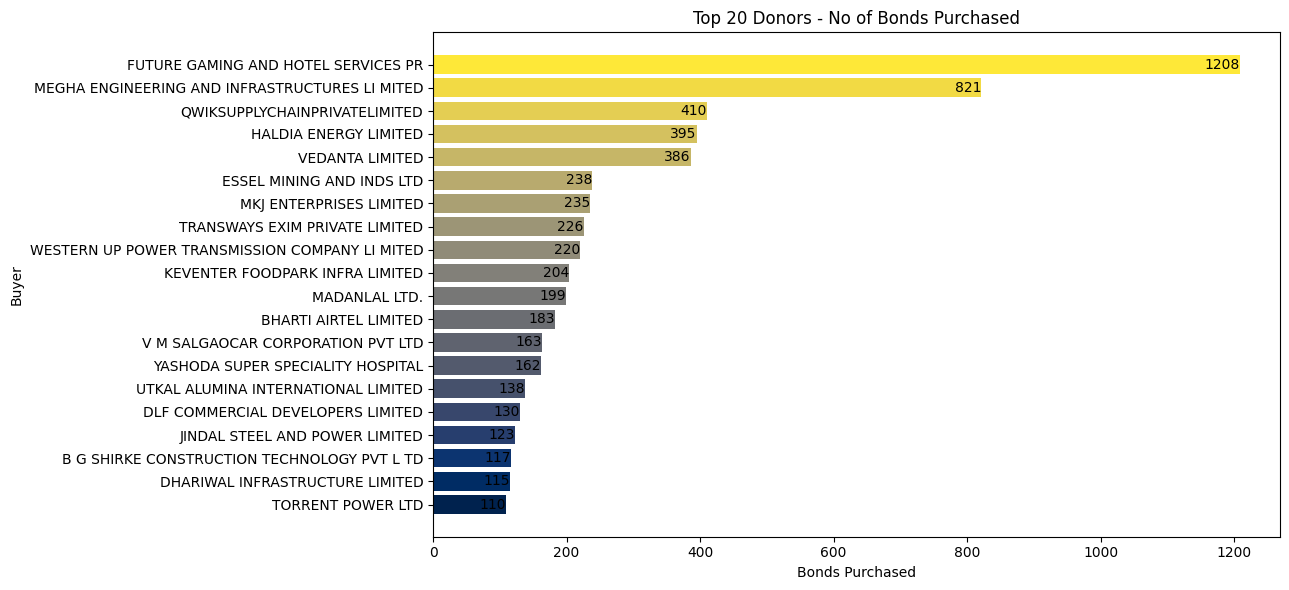

In [14]:
bonds_by_donor = donors['Donor'].value_counts().reset_index()
bonds_by_donor.columns=['Donor','Bonds purchased'] #rename
#sorting
bonds_by_donor=bonds_by_donor.sort_values(by='Bonds purchased',ascending=False)

top20 = bonds_by_donor.head(20) #new TOP 20 buyers wrt bonds bought
#sorting
top20=top20.sort_values(by ="Bonds purchased",ascending=True)


num_colors = len(top20)
# Generate a range of colors using a gradient
colors = plt.cm.cividis(np.linspace(0, 1, num_colors))

plt.figure(figsize=(13,6))
bar = plt.barh(top20['Donor'],top20['Bonds purchased'], color = colors)

# Add labels for the bars
for bar, value in zip(bar, top20['Bonds purchased']):
    plt.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height()/2, f'{int(value)}', 
             va='center', ha='right')  

plt.title("Top 20 Donors - No of Bonds Purchased")
plt.xlabel('Bonds Purchased')
plt.ylabel('Buyer')
plt.tight_layout()
plt.show()




Avg.Monthly Donations

<Figure size 1000x500 with 0 Axes>

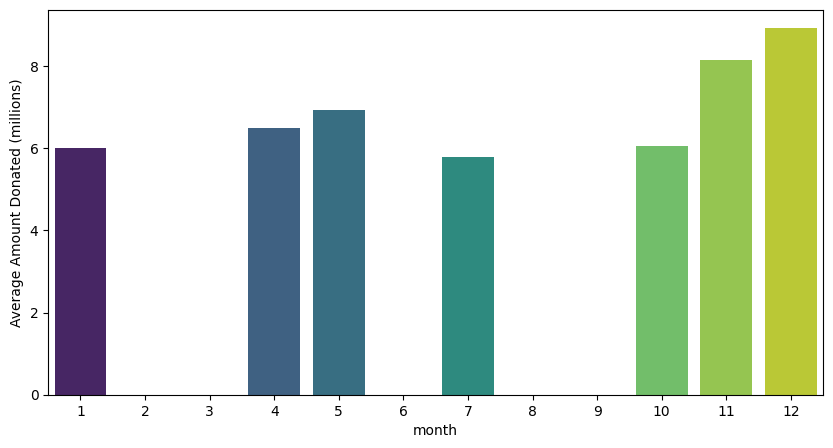

In [15]:
donors['month'] = donors.index.month
Donation_by_month=donors.groupby('month')['Amount'].mean().reset_index()
Donation_by_month['Amount'] = Donation_by_month['Amount']/1000000
Donation_by_month.columns =['month','Average Amount Donated (millions)']
Donation_by_month.set_index('month',inplace=True)

Donation_by_month_full=Donation_by_month.reindex(range(1,13))

plt.figure(figsize=(10,5))
plt.figure(figsize = (10,5))
sns.barplot(x=Donation_by_month_full.index, y='Average Amount Donated (millions)', data=Donation_by_month_full,palette='viridis')
plt.ylabel=('Amount')
plt.show()

Avg. Daily Donations

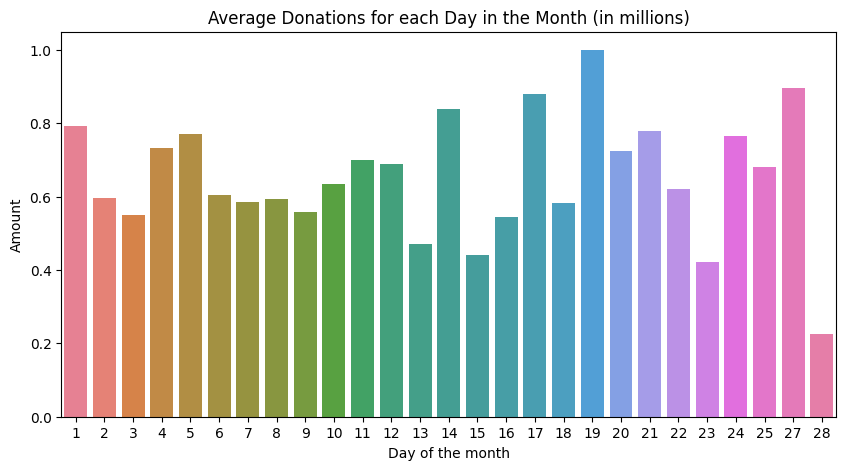

In [20]:
donors['day']=donors.index.day
day=donors[["Donor","Amount",'day']]
donation_day=day.groupby('day')['Amount'].mean().reset_index()
donation_day['Amount']=donation_day['Amount']/10000000

plt.figure(figsize = (10,5))
plt.title("Average Donations for each Day in the Month (in millions)")
sns.barplot(x = 'day', y = 'Amount', data = donation_day,palette='husl')
plt.xlabel('Day of the month')
plt.show()
